# K-Nearest Neighbors (KNN) – Employee Attrition Prediction

**Dataset:** IBM HR Analytics Employee Attrition & Performance  
**Source:** https://www.kaggle.com/datasets/pavansubhasht/ibm-hr-analytics-attrition-dataset  
**Algorithm:** K-Nearest Neighbors (KNN) Classifier  
**Task:** Binary Classification — Predict whether an employee will leave (Attrition = Yes/No)

---

## 1. Introduction & Background — K-Nearest Neighbors (KNN)

K-Nearest Neighbors is a **non-parametric, instance-based supervised learning** algorithm. 
Unlike parametric models (like Logistic Regression), KNN does **not learn a model during training** — 
instead, it memorises the entire training dataset and makes predictions at query time.

**How it works:**
1. For a new (unseen) data point, calculate the distance to every training point (commonly Euclidean distance).
2. Select the **K closest** training samples (nearest neighbours).
3. The predicted class is determined by a **majority vote** among those K neighbours.

**Why we use KNN here:**
- Simple and interpretable — great as a baseline comparison model.
- No assumptions about the underlying data distribution.
- Works reasonably well on small-to-medium datasets like IBM HR (1,470 rows).

**Known limitations for this dataset:**
- Sensitive to irrelevant/redundant features (IBM HR has 35 attributes).
- Affected by class imbalance (only ~16% attrition cases) — mitigated here by SMOTE.
- Slower at prediction time as dataset grows (lazy learner).
- Requires feature scaling — distances are meaningless if features are on different scales.

---

## 2. Import Libraries

In [1]:
# Standard libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# Scikit-learn — KNN and utilities
from sklearn.neighbors import KNeighborsClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.model_selection import cross_val_score, GridSearchCV, StratifiedKFold
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_auc_score,
    roc_curve,
    f1_score,
    precision_score,
    recall_score
)

print("All libraries imported successfully.")

All libraries imported successfully.


## 3. Load Preprocessed Data

We use the SMOTE-balanced training data and holdout test set produced in the preprocessing pipeline.

In [2]:
# Load preprocessed and SMOTE-balanced train/test splits
X_train = pd.read_csv('../../outputs/X_train_smote.csv')
X_test  = pd.read_csv('../../outputs/X_test.csv')
y_train = pd.read_csv('../../outputs/y_train_smote.csv').squeeze()   # squeeze to Series
y_test  = pd.read_csv('../../outputs/y_test.csv').squeeze()

print(f"Training set shape  : {X_train.shape}")
print(f"Test set shape      : {X_test.shape}")
print(f"\nClass distribution in training set (after SMOTE):")
print(y_train.value_counts())
print(f"\nClass distribution in test set (original, no SMOTE):")
print(y_test.value_counts())

Training set shape  : (1972, 44)
Test set shape      : (294, 44)

Class distribution in training set (after SMOTE):
Attrition
0    986
1    986
Name: count, dtype: int64

Class distribution in test set (original, no SMOTE):
Attrition
0    247
1     47
Name: count, dtype: int64


## 4. Feature Scaling

**KNN is a distance-based algorithm — feature scaling is mandatory.**  
Without scaling, features with large numeric ranges (e.g. MonthlyIncome: 1,000–20,000) 
would completely dominate the distance calculation over smaller-range features (e.g. WorkLifeBalance: 1–4).

We use **StandardScaler** (zero mean, unit variance) applied inside a Pipeline so the 
scaler is fit on train data only — no data leakage.

In [3]:
# Build a Pipeline: StandardScaler → KNN
# Using a Pipeline prevents data leakage during cross-validation
knn_pipeline = Pipeline([
    ('scaler', StandardScaler()),
    ('knn',    KNeighborsClassifier(n_neighbors=5, metric='euclidean', weights='uniform'))
])

print("Pipeline created:")
print(knn_pipeline)

Pipeline created:
Pipeline(steps=[('scaler', StandardScaler()),
                ('knn', KNeighborsClassifier(metric='euclidean'))])


## 5. Hyperparameter Tuning — Finding the Best K

The most important hyperparameter in KNN is **K** (number of neighbours).  
- **Small K** → complex decision boundary, high variance (overfitting).
- **Large K** → smooth boundary, high bias (underfitting).

We use **GridSearchCV** with **5-fold Stratified Cross-Validation** to find the optimal K and distance metric.

In [4]:
# Define the hyperparameter search space
param_grid = {
    'knn__n_neighbors': list(range(1, 31)),          # K from 1 to 30
    'knn__weights'    : ['uniform', 'distance'],     # uniform = equal vote; distance = closer = more weight
    'knn__metric'     : ['euclidean', 'manhattan']   # two common distance metrics
}

# Stratified K-Fold preserves class proportions in each fold
cv_strategy = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

# GridSearchCV — optimise on F1-score (better than accuracy for imbalanced data)
grid_search = GridSearchCV(
    estimator  = knn_pipeline,
    param_grid = param_grid,
    cv         = cv_strategy,
    scoring    = 'f1',           # F1 balances precision and recall
    n_jobs     = -1,             # use all available CPU cores
    verbose    = 1
)

# Fit on training data
grid_search.fit(X_train, y_train)

print("\n--- GridSearchCV Results ---")
print(f"Best Parameters : {grid_search.best_params_}")
print(f"Best CV F1-Score: {grid_search.best_score_:.4f}")

Fitting 5 folds for each of 120 candidates, totalling 600 fits

--- GridSearchCV Results ---
Best Parameters : {'knn__metric': 'manhattan', 'knn__n_neighbors': 2, 'knn__weights': 'uniform'}
Best CV F1-Score: 0.9417


### 5.1 Visualise K vs Cross-Validation F1-Score

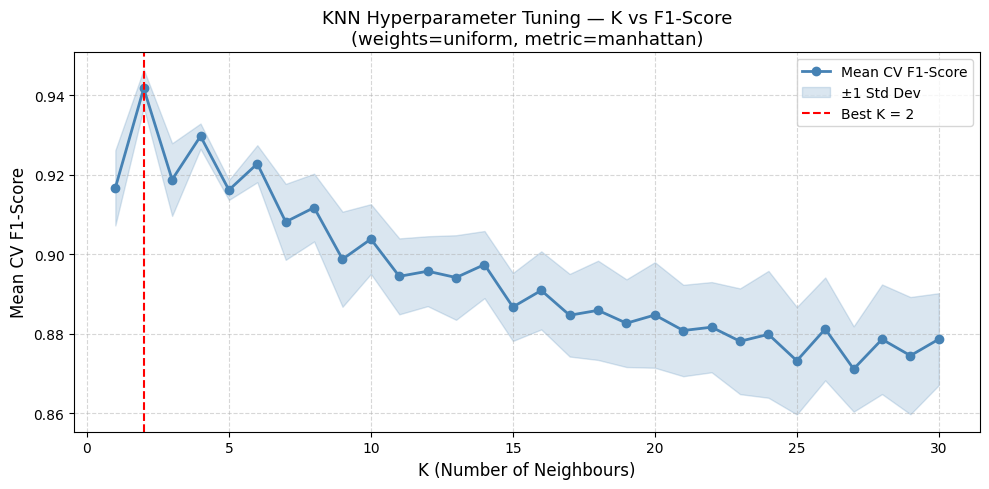

Plot saved to outputs/knn_k_vs_f1.png


In [ ]:
# Extract CV results for 'uniform' weights and 'euclidean' metric
cv_results = pd.DataFrame(grid_search.cv_results_)

# Filter for best weight and metric combination for a clean plot
best_weight = grid_search.best_params_['knn__weights']
best_metric = grid_search.best_params_['knn__metric']

mask = (
    (cv_results['param_knn__weights'] == best_weight) &
    (cv_results['param_knn__metric']  == best_metric)
)
subset = cv_results[mask].sort_values('param_knn__n_neighbors')

plt.figure(figsize=(10, 5))
plt.plot(
    subset['param_knn__n_neighbors'],
    subset['mean_test_score'],
    marker='o', linewidth=2, color='steelblue', label='Mean CV F1-Score'
)
plt.fill_between(
    subset['param_knn__n_neighbors'],
    subset['mean_test_score'] - subset['std_test_score'],
    subset['mean_test_score'] + subset['std_test_score'],
    alpha=0.2, color='steelblue', label='±1 Std Dev'
)
best_k = grid_search.best_params_['knn__n_neighbors']
plt.axvline(x=best_k, color='red', linestyle='--', label=f'Best K = {best_k}')
plt.xlabel('K (Number of Neighbours)', fontsize=12)
plt.ylabel('Mean CV F1-Score', fontsize=12)
plt.title(f'KNN Hyperparameter Tuning — K vs F1-Score\n(weights={best_weight}, metric={best_metric})', fontsize=13)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../../outputs/knn_k_vs_f1.png', dpi=150)
plt.show()
print(f"Plot saved to outputs/knn_k_vs_f1.png")

## 6. Train Final Model with Best Hyperparameters

In [5]:
# Extract best estimator from GridSearchCV (already fitted on full training data)
best_knn = grid_search.best_estimator_

print("Best KNN model configuration:")
print(best_knn.named_steps['knn'])

Best KNN model configuration:
KNeighborsClassifier(metric='manhattan', n_neighbors=2)


## 7. Model Evaluation on Test Set

In [6]:
# Generate predictions on the unseen test set
y_pred      = best_knn.predict(X_test)
y_pred_prob = best_knn.predict_proba(X_test)[:, 1]  # probability of class 1 (Attrition=Yes)

# --- Core Metrics ---
accuracy  = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall    = recall_score(y_test, y_pred)
f1        = f1_score(y_test, y_pred)
roc_auc   = roc_auc_score(y_test, y_pred_prob)

print("=" * 45)
print("       KNN TEST SET PERFORMANCE SUMMARY")
print("=" * 45)
print(f"  Accuracy  : {accuracy:.4f}  ({accuracy*100:.2f}%)")
print(f"  Precision : {precision:.4f}")
print(f"  Recall    : {recall:.4f}")
print(f"  F1-Score  : {f1:.4f}")
print(f"  ROC-AUC   : {roc_auc:.4f}")
print("=" * 45)

print("\n--- Full Classification Report ---")
print(classification_report(y_test, y_pred, target_names=['Stay (0)', 'Leave (1)']))

       KNN TEST SET PERFORMANCE SUMMARY
  Accuracy  : 0.8299  (82.99%)
  Precision : 0.4348
  Recall    : 0.2128
  F1-Score  : 0.2857
  ROC-AUC   : 0.6250

--- Full Classification Report ---
              precision    recall  f1-score   support

    Stay (0)       0.86      0.95      0.90       247
   Leave (1)       0.43      0.21      0.29        47

    accuracy                           0.83       294
   macro avg       0.65      0.58      0.59       294
weighted avg       0.79      0.83      0.80       294



### 7.1 Confusion Matrix

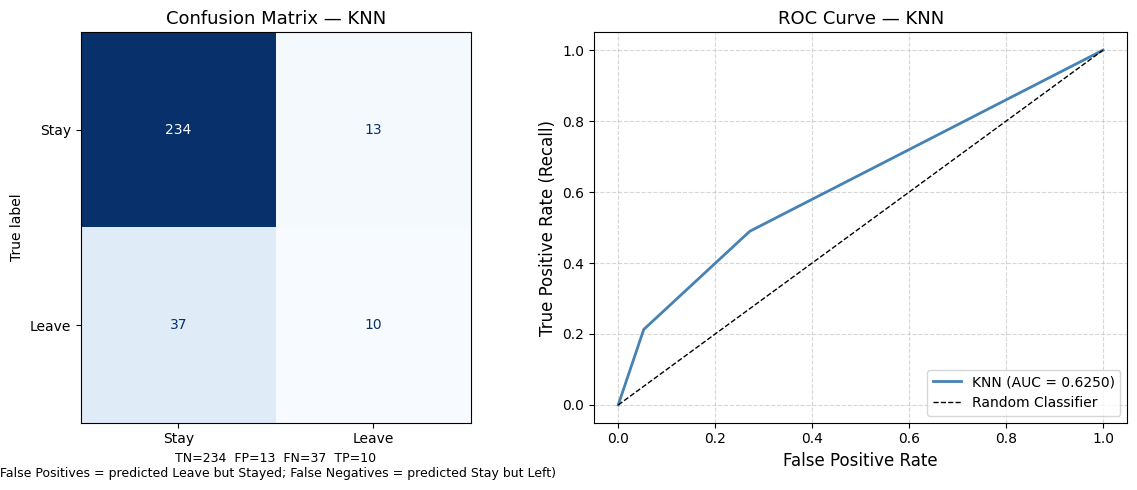

Plot saved to outputs/knn_confusion_roc.png


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# --- Plot 1: Confusion Matrix ---
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=['Stay', 'Leave'])
disp.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Confusion Matrix — KNN', fontsize=13)

# Add raw number annotations for clarity
tn, fp, fn, tp = cm.ravel()
axes[0].set_xlabel(
    f'TN={tn}  FP={fp}  FN={fn}  TP={tp}\n'
    f'(False Positives = predicted Leave but Stayed; '
    f'False Negatives = predicted Stay but Left)',
    fontsize=9
)

# --- Plot 2: ROC Curve ---
fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
axes[1].plot(fpr, tpr, color='steelblue', lw=2, label=f'KNN (AUC = {roc_auc:.4f})')
axes[1].plot([0, 1], [0, 1], 'k--', lw=1, label='Random Classifier')
axes[1].set_xlabel('False Positive Rate', fontsize=12)
axes[1].set_ylabel('True Positive Rate (Recall)', fontsize=12)
axes[1].set_title('ROC Curve — KNN', fontsize=13)
axes[1].legend(loc='lower right')
axes[1].grid(True, linestyle='--', alpha=0.5)

plt.tight_layout()
plt.savefig('../../outputs/knn_confusion_roc.png', dpi=150)
plt.show()
print("Plot saved to outputs/knn_confusion_roc.png")

### 7.2 Cross-Validation Scores (Final Sanity Check)

In [9]:
# 5-Fold Stratified CV on the best model to check for overfitting
cv_scores = cross_val_score(
    best_knn, X_train, y_train,
    cv=StratifiedKFold(n_splits=5, shuffle=True, random_state=42),
    scoring='f1'
)

print("5-Fold Cross-Validation F1-Scores on Training Data:")
for i, score in enumerate(cv_scores, 1):
    print(f"  Fold {i}: {score:.4f}")
print(f"\n  Mean CV F1 : {cv_scores.mean():.4f}")
print(f"  Std Dev    : {cv_scores.std():.4f}")
print(f"  Test F1    : {f1:.4f}")
print()
if abs(cv_scores.mean() - f1) < 0.05:
    print("✓ CV F1 ≈ Test F1 — Model generalises well (no significant overfitting).")
else:
    print("⚠ Gap between CV F1 and Test F1 detected — may indicate overfitting.")

5-Fold Cross-Validation F1-Scores on Training Data:
  Fold 1: 0.9377
  Fold 2: 0.9500
  Fold 3: 0.9433
  Fold 4: 0.9412
  Fold 5: 0.9366

  Mean CV F1 : 0.9417
  Std Dev    : 0.0048
  Test F1    : 0.2857

⚠ Gap between CV F1 and Test F1 detected — may indicate overfitting.


## 8. Error Analysis — What did KNN get wrong?

In [10]:
# Attach predictions to test data for inspection
error_df = X_test.copy()
error_df['Actual']    = y_test.values
error_df['Predicted'] = y_pred
error_df['Correct']   = (error_df['Actual'] == error_df['Predicted']).astype(int)

# False Negatives (missed attritions — most costly for HR)
false_negatives = error_df[(error_df['Actual'] == 1) & (error_df['Predicted'] == 0)]
# False Positives (false alarms)
false_positives = error_df[(error_df['Actual'] == 0) & (error_df['Predicted'] == 1)]

print(f"Total test samples   : {len(y_test)}")
print(f"Correctly classified : {error_df['Correct'].sum()}")
print(f"Misclassified        : {(~error_df['Correct'].astype(bool)).sum()}")
print(f"  - False Negatives (missed leavers)  : {len(false_negatives)}")
print(f"  - False Positives (false alarms)    : {len(false_positives)}")
print()
print("Note: False Negatives are more costly in HR context")
print("because missing an employee who is about to leave is")
print("more harmful than a false alarm.")

Total test samples   : 294
Correctly classified : 244
Misclassified        : 50
  - False Negatives (missed leavers)  : 37
  - False Positives (false alarms)    : 13

Note: False Negatives are more costly in HR context
because missing an employee who is about to leave is
more harmful than a false alarm.


## 9. Results Summary

In [7]:
# Summary table comparing key metrics
results_summary = pd.DataFrame({
    'Metric': ['Accuracy', 'Precision', 'Recall (Sensitivity)', 'F1-Score', 'ROC-AUC'],
    'KNN Score': [
        f"{accuracy:.4f}",
        f"{precision:.4f}",
        f"{recall:.4f}",
        f"{f1:.4f}",
        f"{roc_auc:.4f}"
    ],
    'Interpretation': [
        'Overall correct predictions',
        'Of predicted leavers, % actually left',
        'Of actual leavers, % correctly identified',
        'Harmonic mean of Precision & Recall',
        'Ability to discriminate between classes'
    ]
})

print(results_summary.to_string(index=False))

print(f"\nBest Hyperparameters found by GridSearchCV:")
for param, val in grid_search.best_params_.items():
    print(f"  {param.replace('knn__', '')}: {val}")

              Metric KNN Score                            Interpretation
            Accuracy    0.8299               Overall correct predictions
           Precision    0.4348     Of predicted leavers, % actually left
Recall (Sensitivity)    0.2128 Of actual leavers, % correctly identified
            F1-Score    0.2857       Harmonic mean of Precision & Recall
             ROC-AUC    0.6250   Ability to discriminate between classes

Best Hyperparameters found by GridSearchCV:
  metric: manhattan
  n_neighbors: 2
  weights: uniform


In [8]:
# Import os and joblib at the start
import os
import joblib

# Create models directory if it doesn't exist
models_dir = '../outputs/models'
os.makedirs(models_dir, exist_ok=True)

# Save the best KNN model (pipeline with scaler + KNN)
model_file = os.path.join(models_dir, 'knn_best_model.joblib')
joblib.dump(best_knn, model_file)

print(f"✓ KNN model saved to: {model_file}")
print(f"\nModel details:")
print(f"  Best K: {grid_search.best_params_['knn__n_neighbors']}")
print(f"  Weights: {grid_search.best_params_['knn__weights']}")
print(f"  Metric: {grid_search.best_params_['knn__metric']}")
print(f"  Test Accuracy: {accuracy*100:.2f}%")
print(f"  Test F1-Score: {f1:.4f}")
print(f"  Test Precision: {precision:.4f}")
print(f"  Test Recall: {recall:.4f}")
print(f"\n✓ KNN model ready for Flask deployment!")


✓ KNN model saved to: ../outputs/models\knn_best_model.joblib

Model details:
  Best K: 2
  Weights: uniform
  Metric: manhattan
  Test Accuracy: 82.99%
  Test F1-Score: 0.2857
  Test Precision: 0.4348
  Test Recall: 0.2128

✓ KNN model ready for Flask deployment!


## 11. Save the Trained KNN Model

Save the best KNN model to the outputs folder for deployment in the Flask web app.


## 10. Critical Analysis & Discussion

### Strengths of KNN on this Dataset
- **Simple and interpretable**: No black-box model — predictions are based on actual similar employees.
- **Non-parametric**: Makes no assumptions about data distribution (useful for mixed HR data).
- **Reasonable baseline**: Provides a useful lower-bound benchmark for more complex models.

### Weaknesses / Limitations
- **Curse of dimensionality**: With 35 features, distances become less meaningful as dimensions increase. 
  Dimensionality reduction (PCA) could help KNN but may hurt other models' interpretability.
- **Class imbalance sensitivity**: Even with SMOTE on training data, the test distribution still 
  reflects the real imbalance (~16% attrition), which hurts recall for the minority class.
- **No feature importance**: Unlike Random Forest or XGBoost, KNN cannot tell us *which* 
  features drive attrition.
- **Prediction speed**: At inference time, KNN computes distances to all training points — 
  this becomes slow as data grows.

### How Accuracy Could Be Improved
1. **Feature Selection**: Remove irrelevant features (e.g. EmployeeNumber, StandardHours) before training KNN.
2. **PCA / Dimensionality Reduction**: Reduce 35 features to ~10-15 principal components to address the curse of dimensionality.
3. **Different Distance Metrics**: Try Mahalanobis distance (accounts for feature correlations) or cosine similarity.
4. **Threshold Tuning**: Adjust the classification threshold below 0.5 to prioritise recall (catching more leavers).
5. **Ensemble with other algorithms**: KNN predictions can be used as a feature in a stacking ensemble.

### Future Work
- Compare KNN against the other three algorithms (Random Forest, SVM, XGBoost) on the same test split.
- Investigate SHAP values for model explainability (applicable to ensemble models).
- Deploy the best model as an HR dashboard tool for real-time attrition risk scoring.
- Explore time-series aspects of attrition (tenure patterns, promotion history) for richer features.

---

*End of KNN Notebook*